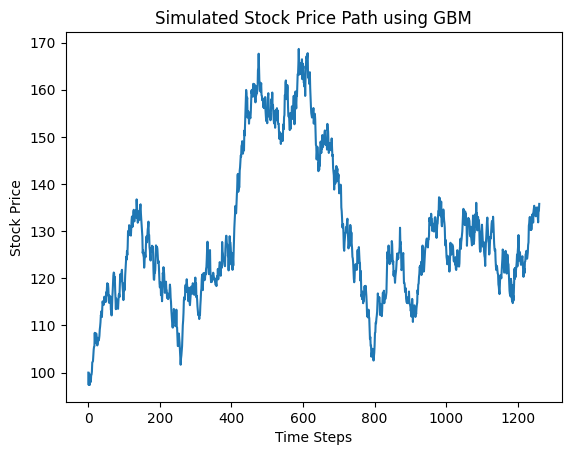

In [96]:
# first step is to generate simulation data using GBM
import numpy as np
import matplotlib.pyplot as plt

def simulate_gbm_euler_scheme(S0, mu, sigma, num_steps, dt = 1/252):
    S = [S0]
    for i in range(num_steps):
        delta_S = mu * S[-1] * dt + sigma * S[-1] * np.sqrt(dt) * np.random.normal()
        S.append(S[-1] + delta_S)
    
    return S

num_steps = 252 * 5 # number of trading days in a year

mu = 0.1  # expected return
sigma = 0.2  # volatility
S0 = 100  # initial stock price

S = simulate_gbm_euler_scheme(S0, mu, sigma, num_steps)

# plot price path
plt.plot(S)
plt.title('Simulated Stock Price Path using GBM')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.show()

In [75]:
# generate experiences using random policy
# policy: random buy/sell and settle the next state
# state: the quartile that the price is in w/ respect to last 50 samples (0-25%, 25-50%, 50-75%, 75-100%)
# action: buy, sell, hold
actions = ['buy', 'sell', 'hold']
experiences = []

# to discretize the state
# function that finds which quartile the current price is in w/ respect to last 50 samples
def find_quartile(price, last_50):
    sorted_samples = np.sort(last_50)
    if price <= sorted_samples[12]:  # 25th percentile
        return 0
    elif price <= sorted_samples[25]:  # 50th percentile
        return 1
    elif price <= sorted_samples[37]:  # 75th percentile
        return 2
    else:  # above 75th percentile
        return 3


for i in range(10):
    S = simulate_gbm_euler_scheme(S0, mu, sigma, num_steps)

    for i in range(51, num_steps - 1):
        state = find_quartile(S[i], S[i-50:i])
        action = np.random.choice(actions)
        next_state = find_quartile(S[i + 1], S[i-50:i + 1])
        reward = next_state - state if action == 'buy' else state - next_state if action == 'sell' else 0
        experiences.append((state, action, reward, next_state))


In [80]:
# make Q-table with randomized initial values
Q_table = np.random.rand(4, 3)  # 4 states, 3 actions

# go through experiences and update Q-table using Q-learning formula
discount_factor = 0.9

print("Old Q-table: \n" + str(Q_table))

for state, action, reward, next_state in experiences:
    # theoretically should converge to correct Q-values over time
    new_Q_value = reward + discount_factor * np.max(Q_table[next_state])
    # update Q-value for the current state-action pair
    Q_table[state, actions.index(action)] = new_Q_value

print("new_Q_table: \n" + str(Q_table))

Old Q-table: 
[[0.31123578 0.84560519 0.81098429]
 [0.59525783 0.88335371 0.00374503]
 [0.66802432 0.48595176 0.06063946]
 [0.9289731  0.48516376 0.02374854]]
new_Q_table: 
[[7.02834169 6.56581199 6.56581199]
 [6.80923079 7.56581199 6.80923079]
 [6.92834169 5.58704632 6.51195677]
 [4.32176109 7.23550752 4.80195677]]


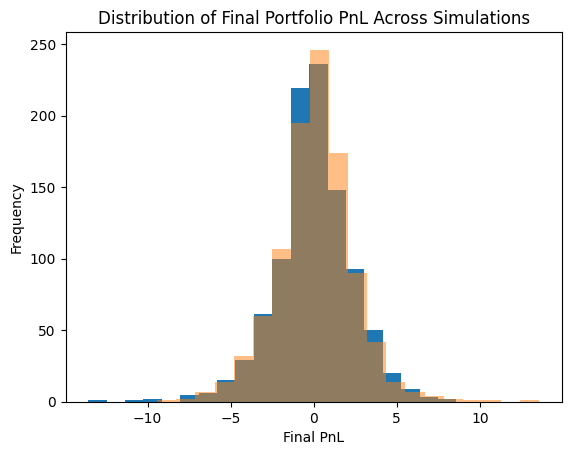

In [93]:
# use learned Q-table on new simulated price path

# get distribution of final portfolio PnL across multiple simulations
# compare to baseline strategy of random buy/sell decisions

num_simulations = 1000

final_PnL = []
baseline_final_PnL = []

for i in range(num_simulations):
    S = simulate_gbm_euler_scheme(S0, mu, sigma, num_steps)
    portfolio_value = [0]
    baseline_portfolio_value = [0]

    for j in range(51, num_steps - 1):
        state = find_quartile(S[j], S[j-50:j])
    action_index = np.argmax(Q_table[state])  # choose action with highest Q-value
    action = actions[action_index]

    # Baseline strategy: random buy/sell decisions
    baseline_action = np.random.choice(['buy', 'sell'])
    if baseline_action == 'buy':
        baseline_portfolio_value.append(baseline_portfolio_value[-1] + S[j + 1] - S[j])
    elif baseline_action == 'sell':
        baseline_portfolio_value.append(baseline_portfolio_value[-1] + S[j] - S[j + 1])

    if action == 'buy':
        portfolio_value.append(portfolio_value[-1] + S[j + 1] - S[j])  # profit from buying and selling at next time step
    elif action == 'sell':
        portfolio_value.append(portfolio_value[-1] + S[j] - S[j + 1])  # profit from selling and buying back at next time step

    # plt.plot(portfolio_value)

    final_PnL.append(portfolio_value[-1])
    baseline_final_PnL.append(baseline_portfolio_value[-1])

plt.hist(final_PnL, bins=20)
plt.hist(baseline_final_PnL, bins=20, alpha=0.5, label='Baseline Strategy')
plt.title('Distribution of Final Portfolio PnL Across Simulations')
plt.xlabel('Final PnL')
plt.ylabel('Frequency')
plt.show()
